# Makemore Part 3 — SOP 复习本

这是独立的 SOP 练习页面，不混进主笔记。

**规则：** 概念不查，API/语法可以查。写完每个 Stage 发给 Claude 评审。

---

# Stage 1 · Whiteboard Recall · 45 min

五道题，从记忆重建。不要翻笔记。

## Q1 · Problem Definition

**这节课要解决什么问题？用 2-3 句话回答。**

提示：从 Part 2 的网络出发，训练时会出现什么症状？根本原因是什么？

**你的回答：**

1. 首先如果hidden layer的params值太高，就会出现hocky stick，根本原因在于前期有一部分的neuron需要训练去降低loss，而前期的loss值太高了，就会让训练的效率降低
2. 在经过hidden layer的时候有一部分neuron会出现不论activate的值怎么变化，都不会影响logits，这些neuron像dead了一样，根本原因在于hidden的那些function会去对linear数据进行nonlinear处理，在这个过程中，就会出现极值或者function的公式原因导致一部分neuron失去training的能力

## Q2 · Kaiming Init 数学推导

**为什么 W 要除以 `√fan_in`？从方差一步步推导。**

提示框架：
```
一层线性变换 y = x₁w₁ + x₂w₂ + ... + xₙwₙ

Var(y) = ?

想让 Var(y) = Var(x)，需要 Var(w) = ?

所以 std(w) = ?
```

**你的推导：**

var（y) = nvar(x)var(w)

var(w) = 1/n

std(w) = (1/n)**0.5





## Q3 · BN Forward 伪代码

**从记忆里写出 BatchNorm1d 的完整 `__call__`，训练和推理两种情况都要有。**

需要包含：
- 训练时用 batch mean/var
- 推理时用 running mean/var  
- normalize → scale & shift
- 更新 running stats（EMA）

In [ ]:
# 从记忆重建 BatchNorm1d.__call__
# 不需要完整 class，只写 forward 逻辑就行

def bn_forward(x, training=True):
    if training:
        mean = xmean  # 填
        var  = xvar  # 填
    else:
        mean = mean_running  # 填
        var  = var_running  # 填
    
    x_norm = (x - xmean) / (xvar)**0.5# 填：归一化公式
    out    = x_norm * gamma + beta  # 填：scale & shift
    
    if training:

        mean_running = (1- momentom) * mean_traning + momentom * mean_traning
        mean_var = (1- momentom) * var_traning + momentom * var_traning
        
        pass 
    
    return out

## Q4 · 与 Part 2 的接口

**Part 3 在 Part 2 的基础上做了哪些改动？列出来。**

提示：想想初始化、网络结构、新增了什么工具。

**你的回答：**

1. kaiming init
2. batch normalization
3. ratio等图表去判断lr

## Q5 · ? 标记

**有哪些地方还没完全搞清楚？诚实标出来。**

**还没懂的点：**

? 
? 

---

# Stage 2 · Diff — Red/Green 结果

| 题 | 结果 | 说明 |
|----|------|------|
| Q1 | 🔴 | hockey stick（output 层）和 dead neurons（hidden 层）混在一起了 |
| Q2 | 🟢 | 方差推导完全正确 |
| Q3 | 🔴 | EMA 两个变量都用了 batch mean，没有保留历史值；缺 eps；缺 no_grad |
| Q4 | 🟡 | 漏了 PyTorchifying；诊断工具描述偏窄 |

---

### Q1 纠错 — 两个问题，两个解法，互不相关

| 问题 | 位置 | 解法 |
|------|------|------|
| Hockey stick | output 层 W2 太大 → logits 不均匀 | `W2 *= 0.1` 或（有 BN 时）`gamma *= 0.1` |
| Dead neurons | hidden 层 W1 太大 → tanh 饱和 | Kaiming init + tanh gain 5/3 |

### Q3 纠错 — EMA 正确写法

```python
# 错的（两边都是 batch mean，历史值丢了）
mean_running = (1 - momentum) * mean_training + momentum * mean_training

# 对的
with torch.no_grad():
    running_mean = (1 - momentum) * running_mean + momentum * xmean
    running_var  = (1 - momentum) * running_var  + momentum * xvar
```

归一化也要加 `eps` 防止除以 0：
```python
x_norm = (x - xmean) / torch.sqrt(xvar + self.eps)
```

### Q4 纠错 — 完整四条

```
1. Kaiming init
2. Batch Normalization
3. PyTorchifying（Linear / BatchNorm1d / Tanh 模块化，API 和 torch.nn 一致）
4. 诊断工具（activation / gradient / weights 三张分布图 + ud ratio 趋势图）
```

---

# Stage 3 · Bounded Variations · 60 min

两个变体，在下面的 code cell 里实现。卡超过 5 分钟就标 `?` 跳过。

## 变体 1：把手写模块换成 torch.nn

Karpathy 说他的 API 和 `torch.nn` 完全一致。把 `Linear` / `BatchNorm1d` / `Tanh` 换成 `nn.Linear` / `nn.BatchNorm1d` / `nn.Tanh`，训练跑通，loss 和原来差不多即为成功。

**注意：** `nn.Linear` 默认有 bias，`nn.BatchNorm1d` 的 momentum 定义和手写版方向相反（`nn` 里 momentum=0.1 对应手写的 `0.1`，不是 `0.9`）。

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---- 数据 ----
words = open('../data/names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
vocab_size = len(stoi)
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42); random.shuffle(words)
n1 = int(0.8*len(words))
Xtr, Ytr = build_dataset(words[:n1])

# ---- TODO: 手写类已删除，直接用 torch.nn ----
# nn.Linear(fan_in, fan_out, bias=False)  --> 等价手写 Linear
# nn.BatchNorm1d(dim)                     --> 等价手写 BatchNorm1d
# nn.Tanh()                               --> 等价手写 Tanh

n_embd = 10; n_hidden = 100
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    nn.Linear(n_embd * block_size, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
    nn.Linear(n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
    nn.Linear(n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
    nn.Linear(n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
    nn.Linear(n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
    nn.Linear(n_hidden, vocab_size, bias=False), nn.BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # nn.BatchNorm1d 的 gamma 叫 weight，beta 叫 bias
    layers[-1].weight.mul_(0.1)

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print('params:', sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

# ---- 训练 1000 步 ----
max_steps = 1000; batch_size = 32; lossi = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    for p in parameters: p.grad = None
    loss.backward()
    for p in parameters: p.data += -0.1 * p.grad
    lossi.append(loss.log10().item())

print(f'final loss: {loss.item():.4f}')
plt.plot(lossi); plt.title('loss (nn version)')

NameError: name 'fan_in' is not defined

## 变体 2：删掉 `weight *= 5/3`，观察 ud 图变化

有了 BN 之后，`weight *= 5/3` 是多余的，还会让 ratio 偏低。删掉这行，重跑训练和 ud 图，看各层 ratio 是不是更接近黑线（`-3`）。

Text(0.5, 1.0, 'ud ratio（删掉 5/3 之前）')

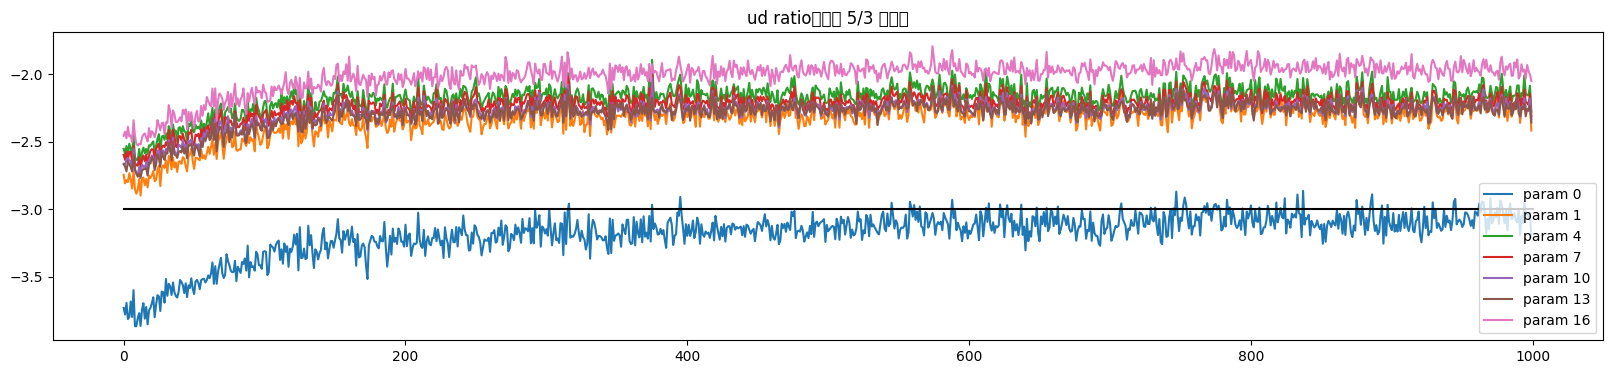

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---- 数据（同上）----
words = open('../data/names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42); random.shuffle(words)
n1 = int(0.8*len(words)); n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])

# ---- 手写版类定义（同变体1，直接复用）----
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias   = torch.zeros(fan_out) if bias else None
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None: self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps; self.momentum = momentum; self.training = True
        self.gamma = torch.ones(dim); self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim); self.running_var = torch.ones(dim)
    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar  = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean; xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * xvar
        return self.out
    def parameters(self): return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x): self.out = torch.tanh(x); return self.out
    def parameters(self): return []

n_embd = 10; n_hidden = 100
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *= 0.1
    # TODO: 把下面这段删掉，然后重跑，对比 ud 图变化
    # for layer in layers[:-1]:
    #     if isinstance(layer, Linear):
    #         layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters: p.requires_grad = True

# ---- 训练（1000步）+ 记录 ud ----
max_steps = 1000; batch_size = 32; lossi = []; ud = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]; x = emb.view(emb.shape[0], -1)
    for layer in layers: x = layer(x)
    loss = F.cross_entropy(x, Yb)
    for p in parameters: p.grad = None
    loss.backward()
    lr = 0.1
    for p in parameters: p.data += -lr * p.grad
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

# ---- ud 图 ----
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k')
plt.legend(legends)
plt.title('ud ratio（删掉 5/3 之前）')
# 删掉 weight *= 5/3 后重跑，看各层是不是更接近黑线

---

## Stage 3 · 关键收获

### 变体 1 的坑

**错误做法：** 把手写类名改成 
- Python 类名不能有点，直接报 SyntaxError

**正确做法：** 删掉所有手写类定义，在  里直接用 


**nn.BatchNorm1d 的细节：**
- gamma 叫 ，beta 叫 （和手写版名字不同）
- 所以缩放最后一层用 ，不是 

### 变体 2 的预期结果

删掉  后，ud 图里各层 ratio 应该更接近黑线（）。
原因：BN 归一化了 forward，weight 变大不影响激活，但会让  这个 ratio 变小、学习变慢。有 BN 之后  是多余的。

---

## Stage 3 · 关键收获

### 变体 1 的坑

**错误做法：** 把手写类名改成 `class nn.Linear:` — Python 类名不能有点，直接报 SyntaxError

**正确做法：** 删掉所有手写类，直接在 `layers = [...]` 里用 `nn.Linear(...)` 等

**nn.BatchNorm1d 和手写版的命名差异：**
- 手写版叫 `gamma` / `beta`
- nn 版叫 `weight` / `bias`
- 所以缩放最后一层：`layers[-1].weight.mul_(0.1)`，不是 `layers[-1].gamma`

### 变体 2 的预期结果

删掉 `weight *= 5/3` 后，ud 图里各层 ratio 应该更接近黑线 `-3`。

原因：BN 已经归一化了 forward pass，weight 变大不影响激活分布，但会让 `grad/weight` ratio 变小，学习变慢。有 BN 之后 `5/3` 是多余且有害的。

---

# Stage 4 · Feynman Explanation（待填）

用自己的话解释给一个懂 Python 但不懂 ML 的人听。

---

# Stage 5 · Archive（待填）

1. 什么变清楚了
2. 什么还卡住
3. 下次从哪里继续